In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:

df = pd.read_csv('/content/Twitter_Data.csv.zip')
print(df.head())

                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0


clean_text    4
category      7
dtype: int64


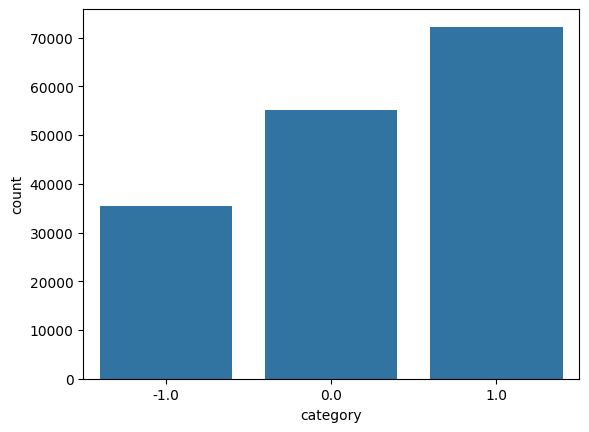

In [6]:

print(df.isnull().sum())
df.dropna(inplace=True)
sns.countplot(x='category', data=df)
plt.show()

In [11]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', "", text)
    text = re.sub(r'[^a-zA-Z\s]', "", text)

    text = text.lower()

    text = text.split()
    text = [stemmer.stem(word) for word in text if word not in stop_words]
    return " ".join(text)


df['clean_text'] = df['clean_text'].astype(str).apply(clean_tweet)

In [12]:

X = df['clean_text']
y = df['category']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [13]:

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.842517027673805

Classification Report:
               precision    recall  f1-score   support

        -1.0       0.82      0.71      0.76      7152
         0.0       0.81      0.92      0.86     11067
         1.0       0.88      0.85      0.86     14375

    accuracy                           0.84     32594
   macro avg       0.84      0.83      0.83     32594
weighted avg       0.84      0.84      0.84     32594



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
